## **PROYECTO DE COMPARACIÓN DE LOS ALGORITMOS HAAR, MTCNN, DLIB y DNN**

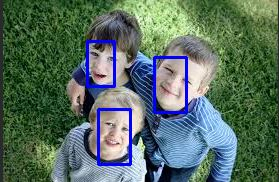

A partir de la ejecución del código inicial, se muestran los resultados de la primera iteración, en la cual se pretende identificar el tiempo que toma en detectar los rostros para una muestra de imágenes.

In [15]:
"""
Created on 04.05.2022
Modified on 01.03.2025
by @author: Paideia
send the the comparison and improvements of algorithms to the Profesor´s mail
manuel.quispe.t@uni.edu.pe
2025-II Distributed Computer Vision
"""

from mtcnn.mtcnn import MTCNN
import cv2
import dlib
import numpy as np
import os
import time
from google.colab.patches import cv2_imshow
import math # Iteracion2 para operaciones de rotación

detector1 = MTCNN()#Multi-task Cascaded CNN-Redes neuronales convolucionales
detector2 = dlib.get_frontal_face_detector()#HOG (Histogram of Oriented Gradients) + SVM
modelFile = "/content/drive/MyDrive/UNI/face_detection/models/res10_300x300_ssd_iter_140000.caffemodel"#OpenCV DNN con modelo Caffe-SSD (Single Shot MultiBox Detector)
configFile = "/content/drive/MyDrive/UNI/face_detection/models/deploy.prototxt.txt"
net = cv2.dnn.readNetFromCaffe(configFile, modelFile)

classifier2 = cv2.CascadeClassifier('/content/drive/MyDrive/UNI/face_detection/models/haarcascade_frontalface2.xml')#Características de Haar
images = os.listdir('/content/drive/MyDrive/UNI/face_detection/faces')
#os.makedirs('/content/drive/MyDrive/UNI/face_detection/faces2/dlib')
#os.makedirs('/content/drive/MyDrive/UNI/face_detection/faces2/dlib_rot')
#os.makedirs('/content/drive/MyDrive/UNI/face_detection/faces2/mtcnn')
#os.makedirs('/content/drive/MyDrive/UNI/face_detection/faces2/dnn')
#os.makedirs('/content/drive/MyDrive/UNI/face_detection/faces2/haar')
#os.makedirs('/content/drive/MyDrive/UNI/face_detection/faces2/haar_lightning')

#Inicio Iteracion2
# FUNCIÓN PARA ROTAR IMÁGENES
def rotar_imagen(imagen, angulo):
    """
    Rota una imagen alrededor de su centro por un ángulo especificado

    Args:
        imagen: imagen de entrada (numpy array)
        angulo: ángulo de rotación en grados (positivo = antihorario)

    Returns:
        imagen_rotada: imagen rotada
        matriz_rotacion: matriz de transformación para coordenadas inversas
    """
    # Obtiene dimensiones de la imagen
    alto, ancho = imagen.shape[:2]

    # Calcula el centro de la imagen
    centro = (ancho // 2, alto // 2)

    # Obtiene la matriz de rotación
    matriz_rotacion = cv2.getRotationMatrix2D(centro, angulo, 1.0)

    # Calcula el coseno y seno del ángulo
    coseno = abs(matriz_rotacion[0, 0])
    seno = abs(matriz_rotacion[0, 1])

    # Calcula nuevas dimensiones para evitar recorte
    nuevo_ancho = int((alto * seno) + (ancho * coseno))
    nuevo_alto = int((alto * coseno) + (ancho * seno))

    # Ajusta la matriz de rotación para el cambio de dimensiones
    matriz_rotacion[0, 2] += (nuevo_ancho / 2) - centro[0]
    matriz_rotacion[1, 2] += (nuevo_alto / 2) - centro[1]

    # Aplica la rotación
    imagen_rotada = cv2.warpAffine(imagen, matriz_rotacion, (nuevo_ancho, nuevo_alto))

    return imagen_rotada, matriz_rotacion

# FUNCIÓN PARA TRANSFORMAR COORDENADAS A LA IMAGEN ORIGINAL
def transformar_coordenadas(puntos, matriz_rotacion):
    """
    Transforma coordenadas de la imagen rotada a la imagen original

    Args:
        puntos: lista de puntos (x, y) en la imagen rotada
        matriz_rotacion: matriz de transformación de rotación

    Returns:
        puntos_originales: puntos transformados a coordenadas originales
    """
    # Convierte los puntos a formato homogéneo (x, y, 1)
    puntos_homogeneos = np.array([[x, y, 1] for x, y in puntos])

    # Calcula la matriz inversa de rotación
    try:
        # Para transformaciones afines, necesitamos la inversa
        matriz_rotacion_inv = cv2.invertAffineTransform(matriz_rotacion)
    except:
        # Fallback: cálculo manual de la inversa para transformaciones afines
        a = matriz_rotacion[0, 0]
        b = matriz_rotacion[0, 1]
        tx = matriz_rotacion[0, 2]
        c = matriz_rotacion[1, 0]
        d = matriz_rotacion[1, 1]
        ty = matriz_rotacion[1, 2]

        det = a * d - b * c
        if det != 0:
            a_inv = d / det
            b_inv = -b / det
            c_inv = -c / det
            d_inv = a / det
            tx_inv = (-d * tx + b * ty) / det
            ty_inv = (c * tx - a * ty) / det

            matriz_rotacion_inv = np.array([[a_inv, b_inv, tx_inv],
                                          [c_inv, d_inv, ty_inv]])
        else:
            # Si no es invertible, retorna matriz identidad
            matriz_rotacion_inv = np.array([[1, 0, 0], [0, 1, 0]])

    # Aplica la transformación inversa
    puntos_transformados = []
    for punto in puntos_homogeneos:
        x_nuevo = matriz_rotacion_inv[0, 0] * punto[0] + matriz_rotacion_inv[0, 1] * punto[1] + matriz_rotacion_inv[0, 2]
        y_nuevo = matriz_rotacion_inv[1, 0] * punto[0] + matriz_rotacion_inv[1, 1] * punto[1] + matriz_rotacion_inv[1, 2]
        puntos_transformados.append((int(x_nuevo), int(y_nuevo)))

    return puntos_transformados
    #Fin Iteracion2

for image in images:
  if image.lower().endswith(('.jpg', '.jpeg', '.png')):
    img = cv2.imread(os.path.join('/content/drive/MyDrive/UNI/face_detection/faces', image))
    # img = cv2.resize(img, None, fx=2, fy=2)
    if img is None:
            print("Could not read")
            continue
    height, width = img.shape[:2]
    img1 = img.copy()# Para Dlib
    img2 = img.copy()# Para DNN
    img3 = img.copy()# Para Haar
    img5 = img.copy()# Para Haar con menor iluminación
    img4 = img.copy()# Para Dlib con rotación iteracion2
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)# Para Dlib y Haar
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)# Para MTCNN

    tiempos = []
    caras_detectadas = []
    inicio_mtcnn = time.time()
    # detect faces in the image
    faces1 = detector1.detect_faces(img_rgb)#MTCNN
    fin_mtcnn = time.time()
    tiempo_mtcnn = fin_mtcnn - inicio_mtcnn
    tiempos.append(tiempo_mtcnn)
    caras_detectadas.append(len(faces1))

    #DBLIB
    inicio_dlib = time.time()
    faces2 = detector2(gray, 2)#Dlib
    fin_dlib = time.time()
    tiempo_dlib = fin_dlib - inicio_dlib
    tiempos.append(tiempo_dlib)
    caras_detectadas.append(len(faces2))

    #Inicio Iteracion2
    #DBLIB con rotación
    inicio_dlib_rot = time.time()
    # Rota la imagen x grados
    angulo_rotacion = 15
    gray_rotado, matriz_rotacion = rotar_imagen(gray, angulo_rotacion)
    # Detecta caras en la imagen rotada
    faces2_rot = detector2(gray_rotado, 2)

    # Transforma las coordenadas de las detecciones a la imagen original
    caras_dlib_rot = []
    for face in faces2_rot:
        # Obtiene las coordenadas del rectángulo en la imagen rotada
        x_rot = face.left()
        y_rot = face.top()
        x1_rot = face.right()
        y1_rot = face.bottom()

        # Puntos de las esquinas del rectángulo
        puntos_rotados = [(x_rot, y_rot), (x1_rot, y1_rot)]

        # Transforma las coordenadas a la imagen original
        puntos_originales = transformar_coordenadas(puntos_rotados, matriz_rotacion)

        # Almacena las coordenadas transformadas
        caras_dlib_rot.append({
            'left': min(puntos_originales[0][0], puntos_originales[1][0]),
            'top': min(puntos_originales[0][1], puntos_originales[1][1]),
            'right': max(puntos_originales[0][0], puntos_originales[1][0]),
            'bottom': max(puntos_originales[0][1], puntos_originales[1][1])
        })

    fin_dlib_rot = time.time()
    tiempo_dlib_rot = fin_dlib_rot - inicio_dlib_rot
    tiempos.append(tiempo_dlib_rot)
    caras_detectadas.append(len(caras_dlib_rot))
    #Fin Iteracion2



    #OpenCV DNN
    inicio_dnn = time.time()
    #Preparar blob para DNN
    blob = cv2.dnn.blobFromImage(cv2.resize(img, (300, 300)),
                                 1.0, (300, 300), (104.0, 117.0, 123.0))

    net.setInput(blob)
    faces3 = net.forward()
    fin_dnn = time.time()
    tiempo_dnn = fin_dnn - inicio_dnn
    tiempos.append(tiempo_dnn)

    caras_dnn = 0
    for i in range (faces3.shape[2]):
      confidence = faces3[0, 0, i, 2]
      if confidence > 0.5:
        caras_dnn += 1
    caras_detectadas.append(caras_dnn)



    inicio_haar = time.time()
    #Haar Cascades
    faces4 = classifier2.detectMultiScale(img)
    fin_haar = time.time()
    tiempo_haar = fin_haar - inicio_haar
    tiempos.append(tiempo_haar)
    caras_detectadas.append(len(faces4))

    #Inicio Iteracion2
    inicio_haar_lighting = time.time()
    #Haar cascade com menor iluminación
    gray_oscuro = cv2.convertScaleAbs(gray, alpha=1, beta=-30)
    faces5 = classifier2.detectMultiScale(gray_oscuro)
    fin_haar_lighting = time.time()
    tiempo_haar_lighting = fin_haar_lighting - inicio_haar_lighting
    tiempos.append(tiempo_haar_lighting)
    caras_detectadas.append(len(faces5))
    #Fin Iteracion2



    print(f"RESULTADOS PARA: {image}")
    print(f"MTCNN:    {tiempo_mtcnn:.4f} segundos - {len(faces1)} caras detectadas")
    print(f"DLib:     {tiempo_dlib:.4f} segundos - {len(faces2)} caras detectadas")
    print(f"DLib Rot: {tiempo_dlib_rot:.4f} segundos - {len(caras_dlib_rot)} caras detectadas (x°)")#Iteracion2
    print(f"OpenCV DNN: {tiempo_dnn:.4f} segundos - {caras_dnn} caras detectadas")
    print(f"Haar:     {tiempo_haar:.4f} segundos - {len(faces4)} caras detectadas")
    print(f"Haar Lighting: {tiempo_haar_lighting:.4f} segundos - {len(faces5)} caras detectadas")#Iteracion2


    #MTCNN
    for result in faces1:

      # MTCNN - retorna diccionario con 'box'
        x, y, w, h = result['box']
        x1, y1 = x + w, y + h
        cv2.rectangle(img, (x, y), (x1, y1), (0, 0, 255), 2)

    #DLIB
    for result in faces2:
      # Dlib - retorna objetos rectangle
        x = result.left()
        y = result.top()
        x1 = result.right()
        y1 = result.bottom()
        cv2.rectangle(img1, (x, y), (x1, y1), (0, 0, 255), 2)

    #Inicio Iteracion2
    # DLIB (CON ROTACIÓN) - Dibuja rectángulos azules para las detecciones con rotación
    for result in caras_dlib_rot:
        x = result['left']
        y = result['top']
        x1 = result['right']
        y1 = result['bottom']
        cv2.rectangle(img4, (x, y), (x1, y1), (255, 0, 0), 2)  # Color azul para diferenciar
    #Fin Iteracion2


    #OPENCV DNN
    for i in range(faces3.shape[2]):
        confidence = faces3[0, 0, i, 2]
        if confidence > 0.5:
          # DNN - requiere procesamiento de coordenadas
            box = faces3[0, 0, i, 3:7] * np.array([width, height, width, height])
            (x, y, x1, y1) = box.astype("int")
            cv2.rectangle(img2, (x, y), (x1, y1), (0, 0, 255), 2)

    #HAAR
    for result in faces4:
      # Haar - retorna (x, y, w, h)
        x, y, w, h = result
        x1, y1 = x + w, y + h
        cv2.rectangle(img3, (x, y), (x1, y1), (0, 0, 255), 2)

    #HARR_LIGHTNING
    for result in faces5:
      # Haar - retorna (x, y, w, h)
        x, y, w, h = result
        x1, y1 = x + w, y + h
        cv2.rectangle(img5, (x, y), (x1, y1), (255, 0, 0), 2)# Color azul para diferenciar

    cv2.imwrite(os.path.join('/content/drive/MyDrive/UNI/face_detection/faces2', 'mtcnn', image), img)
    cv2.imwrite(os.path.join('/content/drive/MyDrive/UNI/face_detection/faces2', 'dlib', image), img1)
    cv2.imwrite(os.path.join('/content/drive/MyDrive/UNI/face_detection/faces2', 'dlib_rot', image), img4)
    cv2.imwrite(os.path.join('/content/drive/MyDrive/UNI/face_detection/faces2', 'dnn', image), img2)
    cv2.imwrite(os.path.join('/content/drive/MyDrive/UNI/face_detection/faces2', 'haar', image), img3)
    cv2.imwrite(os.path.join('/content/drive/MyDrive/UNI/face_detection/faces2', 'haar_lightning', image), img5)

    cv2_imshow(img) # Resultados MTCNN
    cv2_imshow(img1)# Resultados Dlib
    cv2_imshow(img4) # Resultados Dlib (con rotación x° - azul)-Iteracion2
    cv2_imshow(img2)# Resultados DNN
    cv2_imshow(img3) # Resultados Haar
    cv2_imshow(img5) # Resultados Haar_LIGHTNING
    #cv2.waitKey(0)
    #cv2.destroyAllWindows()


#from google.colab import drive
#drive.mount('/content/drive')

Output hidden; open in https://colab.research.google.com to view.